# This put together some poential analysis of BC.

Kexin Dong

Feb 19, 2026

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns
import warnings
import os 
import functools
import upsetplot
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
import re
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   
mpl.rcParams['ps.fonttype'] = 42 
mpl.rcParams['text.usetex'] = False
from matplotlib_venn import venn2
from sklearn.decomposition import PCA

In [26]:
LIB = pd.read_csv('MBESv2_focused_with_PAM.csv', index_col=0)
LIB_OG = pd.read_csv('MBESv2_CORRECTED.csv', index_col=0)

In [58]:
LFC_ABE = pd.read_csv('LFC-FDR/focused/ABE_LFC_FDR_df_focused.csv')
LFC_CBE = pd.read_csv('LFC-FDR/focused/CBE_LFC_FDR_df_focused.csv')

LFC_ABE_OG = pd.read_csv('LFC-FDR/og/ABE_LFC_FDR_df_og.csv')
LFC_CBE_OG = pd.read_csv('LFC-FDR/og/CBE_LFC_FDR_df_og.csv')

LFC_ABE_VS_BC = pd.read_csv('LFC-FDR/focused/ABE_LFC_FDR_df_vs_bc.csv')
LFC_CBE_VS_BC = pd.read_csv('LFC-FDR/focused/CBE_LFC_FDR_df_vs_bc.csv')

In [59]:
#and perform comparison
FDR_cutoff = .1
input_reads_cutoff = 100
input_reads_cutoff_og = 10
above_threshold_gRNAs_focused = list(LFC_CBE[(LFC_CBE['sensor_reads']>=input_reads_cutoff)]) + list(LFC_ABE[LFC_ABE['sensor_reads']>=input_reads_cutoff]['gRNA_id'])

# for focused library
fishers_hits_CBE_focused_enrichers = []
fishers_hits_CBE_focused_depleters = []
fishers_hits_ABE_focused_enrichers = []
fishers_hits_ABE_focused_depleters = []
fishers_ABE_hits = []
fishers_CBE_hits = []

conditions_focused = ['d15', 'spleen', 'bm', 'men']
name_dict_focused = dict(zip(
    conditions_focused,
    ['In Vitro','Spleen','Bone Marrow', 'Meninges']
))

In [60]:
LFC_cutoff = 1
for tissue in conditions_focused:
    # fishers
        # focused
    ABE_fishers_enrichers = LFC_ABE[(LFC_ABE[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_ABE['gRNA_id'].isin(above_threshold_gRNAs_focused)) & (LFC_ABE[f'LFC_median_{tissue}']>LFC_cutoff)]
    CBE_fishers_enrichers = LFC_CBE[(LFC_CBE[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_CBE['gRNA_id'].isin(above_threshold_gRNAs_focused)) & (LFC_CBE[f'LFC_median_{tissue}']>LFC_cutoff)]
    ABE_fishers_depleters = LFC_ABE[(LFC_ABE[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_ABE['gRNA_id'].isin(above_threshold_gRNAs_focused)) & (LFC_ABE[f'LFC_median_{tissue}']< -LFC_cutoff)]
    CBE_fishers_depleters = LFC_CBE[(LFC_CBE[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_CBE['gRNA_id'].isin(above_threshold_gRNAs_focused)) & (LFC_CBE[f'LFC_median_{tissue}']< -LFC_cutoff)]

    ABE_fishers_hits = pd.concat([ABE_fishers_enrichers, ABE_fishers_depleters]).reset_index(drop=True)
    CBE_fishers_hits = pd.concat([CBE_fishers_enrichers, CBE_fishers_depleters]).reset_index(drop=True)
    # # stouffers
    #     # focused
    # ABE_stouffers = LFC_ABE[(LFC_ABE[f'FDR_{tissue}_stouffers']<FDR_cutoff) & (LFC_ABE['gRNA_id'].isin(above_threshold_gRNAs_focused))]
    # CBE_NGG_stouffers = LFC_CBE[(LFC_CBE[f'FDR_{tissue}_stouffers']<FDR_cutoff) & (LFC_CBE['gRNA_id'].isin(above_threshold_gRNAs_focused))]

    fishers_hits_ABE_focused_depleters.append(list(ABE_fishers_depleters['gRNA_id']))
    fishers_hits_ABE_focused_enrichers.append(list(ABE_fishers_enrichers['gRNA_id']))
    fishers_hits_CBE_focused_depleters.append(list(CBE_fishers_depleters['gRNA_id']))
    fishers_hits_CBE_focused_enrichers.append(list(CBE_fishers_enrichers['gRNA_id']))

    fishers_ABE_hits.append(list(ABE_fishers_hits['gRNA_id']))
    fishers_CBE_hits.append(list(CBE_fishers_hits['gRNA_id']))

In [61]:
#and perform comparison
FDR_cutoff = .1
input_reads_cutoff = 100
input_reads_cutoff_og = 10
above_threshold_gRNAs_focused_bc = list(LFC_CBE_VS_BC[(LFC_CBE_VS_BC['sensor_reads_epo']>=input_reads_cutoff) & (LFC_CBE_VS_BC['sensor_reads_bc']>=input_reads_cutoff) ]['gRNA_id']) + list(LFC_ABE_VS_BC[ (LFC_ABE_VS_BC['sensor_reads_bc']>=input_reads_cutoff) & (LFC_ABE_VS_BC['sensor_reads_epo']>=input_reads_cutoff)]['gRNA_id'])
# for focused library
fishers_hits_CBE_focused_enrichers_vs_bc = []
fishers_hits_CBE_focused_depleters_vs_bc = []
fishers_hits_ABE_focused_enrichers_vs_bc = []
fishers_hits_ABE_focused_depleters_vs_bc = []
fishers_ABE_hits_vs_bc = []
fishers_CBE_hits_vs_bc = []

conditions_focused = ['d15', 'spleen', 'bm', 'men']
name_dict_focused = dict(zip(
    conditions_focused,
    ['In Vitro','Spleen','Bone Marrow', 'Meninges']
))

In [62]:
LFC_cutoff = 1
for tissue in conditions_focused:
    # fishers
        # focused
    ABE_fishers_enrichers_bc = LFC_ABE_VS_BC[(LFC_ABE_VS_BC[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_ABE_VS_BC['gRNA_id'].isin(above_threshold_gRNAs_focused)) & (LFC_ABE_VS_BC[f'LFC_median_{tissue}']>LFC_cutoff)]
    CBE_fishers_enrichers_bc = LFC_CBE_VS_BC[(LFC_CBE_VS_BC[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_CBE_VS_BC['gRNA_id'].isin(above_threshold_gRNAs_focused)) & (LFC_CBE_VS_BC[f'LFC_median_{tissue}']>LFC_cutoff)]
    ABE_fishers_depleters_bc = LFC_ABE_VS_BC[(LFC_ABE_VS_BC[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_ABE_VS_BC['gRNA_id'].isin(above_threshold_gRNAs_focused)) & (LFC_ABE_VS_BC[f'LFC_median_{tissue}']< -LFC_cutoff)]
    CBE_fishers_depleters_bc = LFC_CBE_VS_BC[(LFC_CBE_VS_BC[f'FDR_{tissue}_fishers']<FDR_cutoff) & (LFC_CBE_VS_BC['gRNA_id'].isin(above_threshold_gRNAs_focused)) & (LFC_CBE_VS_BC[f'LFC_median_{tissue}']< -LFC_cutoff)]

    ABE_fishers_hits_bc = pd.concat([ABE_fishers_enrichers_bc, ABE_fishers_depleters_bc]).reset_index(drop=True)
    CBE_fishers_hits_bc = pd.concat([CBE_fishers_enrichers_bc, CBE_fishers_depleters_bc]).reset_index(drop=True)
    # # stouffers
    #     # focused
    # ABE_stouffers = LFC_ABE[(LFC_ABE[f'FDR_{tissue}_stouffers']<FDR_cutoff) & (LFC_ABE['gRNA_id'].isin(above_threshold_gRNAs_focused))]
    # CBE_NGG_stouffers = LFC_CBE[(LFC_CBE[f'FDR_{tissue}_stouffers']<FDR_cutoff) & (LFC_CBE['gRNA_id'].isin(above_threshold_gRNAs_focused))]

    fishers_hits_ABE_focused_depleters_vs_bc.append(list(ABE_fishers_depleters_bc['gRNA_id']))
    fishers_hits_ABE_focused_enrichers_vs_bc.append(list(ABE_fishers_enrichers_bc['gRNA_id']))
    fishers_hits_CBE_focused_depleters_vs_bc.append(list(CBE_fishers_depleters_bc['gRNA_id']))
    fishers_hits_CBE_focused_enrichers_vs_bc.append(list(CBE_fishers_enrichers_bc['gRNA_id']))

    fishers_ABE_hits_vs_bc.append(list(ABE_fishers_hits_bc['gRNA_id']))
    fishers_CBE_hits_vs_bc.append(list(CBE_fishers_hits_bc['gRNA_id']))

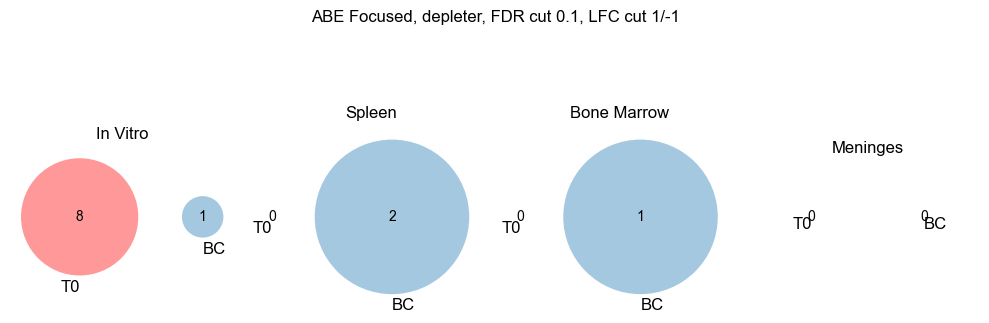

In [63]:
from matplotlib_venn import venn2

fig, axe =plt.subplots(1,4, figsize=(10,4))

for idx, tissue in enumerate(conditions_focused):

    list1 = fishers_hits_ABE_focused_depleters[idx]
    list2 = fishers_hits_ABE_focused_depleters_vs_bc[idx]
    venn2([set(list1), set(list2)], set_labels=('T0', 'BC'), set_colors=("red", "tab:blue"), ax=axe[idx])
    axe[idx].set_title(f'{name_dict_focused[tissue]}')

plt.suptitle('ABE Focused, depleter, FDR cut 0.1, LFC cut 1/-1')
fig.tight_layout()

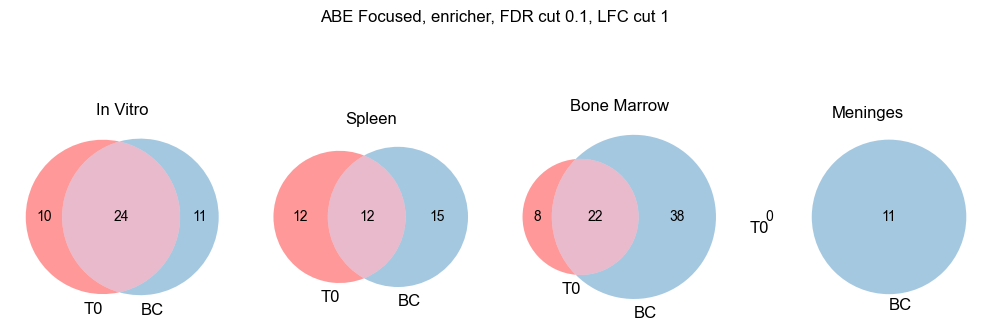

In [66]:
from matplotlib_venn import venn2

fig, axe =plt.subplots(1,4, figsize=(10,4))

for idx, tissue in enumerate(conditions_focused):

    list1 = fishers_hits_ABE_focused_enrichers[idx]
    list2 = fishers_hits_ABE_focused_enrichers_vs_bc[idx]
    venn2([set(list1), set(list2)], set_labels=('T0', 'BC'), set_colors=("red", "tab:blue"), ax=axe[idx])
    axe[idx].set_title(f'{name_dict_focused[tissue]}')

plt.suptitle('ABE Focused, enricher, FDR cut 0.1, LFC cut 1')
fig.tight_layout()

In [71]:
LFC_ABE['classification']

0            targeting guide
1            targeting guide
2            targeting guide
3            targeting guide
4            targeting guide
               ...          
371    non-targeting control
372    non-targeting control
373    non-targeting control
374    non-targeting control
375    non-targeting control
Name: classification, Length: 376, dtype: object

In [73]:
fp = 'counts/focused/'
ABE_BC_COUNTS = pd.read_csv(fp + 'FC_ABE_BC_COUNTS.txt', sep='\t')
ABE_EPO_COUNTS = pd.read_csv(fp + 'FC_ABE_EPO_COUNTS.txt', sep='\t')
# CBE_BC_COUNTS = pd.read_csv(fp + 'CBE_BC_COUNTS.txt', sep='\t')
# CBE_EPO_COUNTS = pd.read_csv(fp + 'CBE_EPO_COUNTS.txt', sep='\t')
ABE_BC_COUNTS = ABE_BC_COUNTS[ABE_BC_COUNTS.columns[2:]]
ABE_EPO_COUNTS = ABE_EPO_COUNTS[ABE_EPO_COUNTS.columns[2:]]
# CBE_EPO_COUNTS = CBE_EPO_COUNTS[CBE_EPO_COUNTS.columns[2:]]
# CBE_BC_COUNTS = CBE_BC_COUNTS[CBE_BC_COUNTS.columns[2:]]

In [74]:
ABE_BC_COUNTS

,lib,input,d5,d15-rep1,d15-rep2,d15-rep3,d15-rep4,d15-rep5,spleen1,spleen2,...,bm1,bm2,bm3,bm4,bm5,men1,men2,men3,men4,men5
0,3604.0,7590.0,9740.0,2905.0,335.0,1953.0,897.0,47.0,2676.0,6806.0,...,4626.0,677.0,5696.0,8075.0,9193.0,189.0,9928.0,599.0,2556.0,10.0
1,18935.0,11979.0,12492.0,38218.0,8043.0,20875.0,24244.0,566.0,9877.0,7621.0,...,2558.0,10021.0,14030.0,13184.0,6526.0,785.0,3639.0,2569.0,3401.0,3093.0
2,44200.0,24893.0,26740.0,159395.0,14552.0,17922.0,24984.0,1288.0,27594.0,20444.0,...,26270.0,2220.0,8740.0,12995.0,5394.0,112814.0,38552.0,81248.0,2512.0,18412.0
3,4691.0,6452.0,8321.0,28166.0,4822.0,7193.0,5613.0,63.0,2562.0,3899.0,...,1068.0,2299.0,62.0,341.0,1546.0,752.0,255.0,8469.0,6497.0,97730.0
4,15547.0,13045.0,15106.0,90114.0,4516.0,21661.0,8079.0,252.0,9388.0,13387.0,...,5088.0,24335.0,6931.0,25028.0,3867.0,481.0,40145.0,4544.0,1352.0,6775.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,51283.0,40323.0,49641.0,266685.0,36486.0,27248.0,76050.0,1107.0,36001.0,35266.0,...,82476.0,123863.0,4442.0,47190.0,4851.0,38375.0,22729.0,54721.0,25292.0,36717.0
372,29168.0,27303.0,35946.0,109799.0,13142.0,27212.0,26981.0,721.0,22663.0,26213.0,...,35798.0,97094.0,9731.0,22846.0,18715.0,11677.0,29545.0,51894.0,15496.0,21683.0
373,51625.0,50847.0,61386.0,340616.0,30955.0,18169.0,65875.0,1308.0,56724.0,41785.0,...,39083.0,4397.0,13708.0,33940.0,17456.0,27987.0,84385.0,383042.0,24419.0,61943.0
374,38285.0,37569.0,45677.0,185270.0,20286.0,56847.0,45879.0,685.0,58389.0,26677.0,...,17330.0,2143.0,2337.0,40502.0,23061.0,42583.0,12758.0,40747.0,58187.0,59043.0
